# Unsupervised Learning for Ethereum Fraud Detection

This notebook applies unsupervised learning to the preprocessed Ethereum transaction dataset.  
We treat the problem as both **clustering** (to discover natural groups of accounts) and **anomaly detection** (to flag unusual accounts).  
The known `FLAG` labels are **never used during training**; they are only used after the fact to evaluate the discovered structure.

**Key rule:**  
- `X` = all features except `FLAG`  
- `y` = `FLAG` (only for evaluation)

We will compare five clustering algorithms and three anomaly detectors, and interpret their results in the context of fraud detection.

---

## 1. Load and Inspect the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Load cleaned data
df = pd.read_csv("cleaned_transactions_dataset.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDescriptive statistics:\n", df.describe())
print("\nFLAG distribution:\n", df["FLAG"].value_counts())
print(f"Fraud prevalence: {df['FLAG'].mean():.2%}")

# Separate X and y (y is only for post-hoc evaluation)
X = df.drop(columns=["FLAG"])
y = df["FLAG"].copy()
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

Shape: (9295, 34)

Columns: ['FLAG', 'avg_min_between_sent_tnx', 'avg_min_between_received_tnx', 'time_diff_first_last_mins', 'sent_tnx', 'received_tnx', 'created_contracts', 'unique_received_from_addresses', 'unique_sent_to_addresses', 'min_value_received', 'max_value_received', 'avg_value_received', 'min_value_sent', 'max_value_sent', 'avg_value_sent', 'total_transactions', 'total_ether_sent', 'total_ether_received', 'total_ether_balance', 'erc20_total_tnxs', 'erc20_total_ether_sent', 'erc20_unique_sent_addresses', 'erc20_unique_received_addresses', 'erc20_unique_received_contract_addresses', 'erc20_min_value_received', 'erc20_max_value_received', 'erc20_avg_value_received', 'erc20_unique_sent_token_names', 'erc20_most_sent_token_type', 'erc20_most_received_token_type', 'sent_received_ratio', 'counterparty_diversity', 'erc20_sent_share', 'erc20_received_share']

Data types:
 FLAG                                          int64
avg_min_between_sent_tnx                    float64
avg_mi

### 2.1 Identify Numerical and Categorical Columns

In [3]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()
print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numerical columns: ['avg_min_between_sent_tnx', 'avg_min_between_received_tnx', 'time_diff_first_last_mins', 'sent_tnx', 'received_tnx', 'created_contracts', 'unique_received_from_addresses', 'unique_sent_to_addresses', 'min_value_received', 'max_value_received', 'avg_value_received', 'min_value_sent', 'max_value_sent', 'avg_value_sent', 'total_transactions', 'total_ether_sent', 'total_ether_received', 'total_ether_balance', 'erc20_total_tnxs', 'erc20_total_ether_sent', 'erc20_unique_sent_addresses', 'erc20_unique_received_addresses', 'erc20_unique_received_contract_addresses', 'erc20_min_value_received', 'erc20_max_value_received', 'erc20_avg_value_received', 'erc20_unique_sent_token_names', 'sent_received_ratio', 'counterparty_diversity', 'erc20_sent_share', 'erc20_received_share']

Categorical columns: ['erc20_most_sent_token_type', 'erc20_most_received_token_type']


### 2.2 Find and Handle Uninformative Features

In [4]:
print(
    X[
        [
            "erc20_unique_received_addresses",
            "erc20_unique_received_contract_addresses"
        ]
    ].corr()
)

                                          erc20_unique_received_addresses  \
erc20_unique_received_addresses                                  1.000000   
erc20_unique_received_contract_addresses                         0.972699   

                                          erc20_unique_received_contract_addresses  
erc20_unique_received_addresses                                           0.972699  
erc20_unique_received_contract_addresses                                  1.000000  


In [5]:
print(X["min_value_received"].value_counts().head(10))
print("Unique:", X["min_value_received"].nunique())

min_value_received
0.000000    1547
4.624973     762
0.009950     229
0.095310     204
0.405465     182
0.693147     174
0.001000     122
0.004988     100
0.048790      74
0.182322      60
Name: count, dtype: int64
Unique: 4589


In [6]:
print(
    X["erc20_min_value_received"].value_counts(normalize=True).head()
)

erc20_min_value_received
0.000000    0.781711
0.848868    0.032921
2.665143    0.022162
0.693147    0.004411
4.615121    0.003981
Name: proportion, dtype: float64


In [7]:
cols = [
    "erc20_min_value_received",
    "erc20_max_value_received",
    "erc20_avg_value_received"
]

print(X[cols].corr())

                          erc20_min_value_received  erc20_max_value_received  \
erc20_min_value_received                  1.000000                  0.178183   
erc20_max_value_received                  0.178183                  1.000000   
erc20_avg_value_received                  0.254191                  0.990181   

                          erc20_avg_value_received  
erc20_min_value_received                  0.254191  
erc20_max_value_received                  0.990181  
erc20_avg_value_received                  1.000000  


In [8]:

X = X.drop(columns=[
    "erc20_most_sent_token_type",
    "erc20_most_received_token_type",
    "total_ether_balance",
    "erc20_unique_received_contract_addresses",
    "erc20_max_value_received",
    "erc20_min_value_received"
])

### 2.4 Scaling
Given the presence of outliers, we use RobustScaler (which uses median and IQR) rather than StandardScaler.

In [9]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("Scaled shape:", X_scaled.shape)
# We use the full X_scaled for all unsupervised modeling
print(f"X_scaled contains {X_scaled.shape[0]} samples.")

Scaled shape: (9295, 27)
X_scaled contains 9295 samples.


## PART A — CLUSTERING
#### We fit five clustering algorithms using only unsupervised criteria for model selection.

---
### 4.1 Helper Functions for Evaluation

In [10]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score
)
from kDBCV.DBCV import DBCV_score

def cluster_metrics(X, labels):
    """
    Compute internal clustering metrics.

    Silhouette, Davies-Bouldin, and Calinski-Harabasz:
        calculated on non-noise points.

    DBCV:
        calculated on the full dataset, including noise points (-1).
    """

    labels = np.asarray(labels)

    # --------------------------------------------------
    # Remove noise for distance-based sklearn metrics
    # --------------------------------------------------
    mask = labels != -1

    X_eval = X[mask]
    labels_eval = labels[mask]

    n_clusters = len(np.unique(labels_eval))

    if n_clusters < 2:
        return {
            "silhouette": np.nan,
            "db": np.nan,
            "ch": np.nan,
            "dbcv": np.nan
        }

    # --------------------------------------------------
    # Silhouette
    # --------------------------------------------------
    sil = silhouette_score(
        X_eval,
        labels_eval
    )

    # --------------------------------------------------
    # Davies-Bouldin
    # --------------------------------------------------
    db = davies_bouldin_score(
        X_eval,
        labels_eval
    )

    # --------------------------------------------------
    # Calinski-Harabasz
    # --------------------------------------------------
    ch = calinski_harabasz_score(
        X_eval,
        labels_eval
    )

    # --------------------------------------------------
    # DBCV
    #
    # IMPORTANT:
    # Keep noise points (-1) for DBCV.
    # --------------------------------------------------
    try:
        dbcv, _ = DBCV_score(
            np.asarray(X),
            labels,
            ind_clust_scores=False
        )

        # DBCV returns -1 when it cannot calculate
        if dbcv == -1:
            dbcv = np.nan

    except Exception as e:
        print(f"DBCV error: {e}")
        dbcv = np.nan

    return {
        "silhouette": sil,
        "db": db,
        "ch": ch,
        "dbcv": dbcv
    }

def cluster_fraud_stats(labels, y):
    """Compute per‑cluster fraud statistics (post-hoc)."""
    unique = sorted(set(labels))
    stats = []
    for cl in unique:
        if cl == -1:
            continue
        mask = labels == cl
        size = mask.sum()
        fraud_count = y[mask].sum()
        fraud_rate = fraud_count / size if size > 0 else 0
        recall = fraud_count / y.sum() if y.sum() > 0 else 0
        stats.append({
            "cluster": cl,
            "size": size,
            "fraud_count": fraud_count,
            "fraud_rate": fraud_rate,
            "fraud_coverage": recall
        })
    return pd.DataFrame(stats)

def external_cluster_metrics(labels, y):
    """
    Post-hoc clustering evaluation using the known fraud labels.

    FLAG is NOT used for training or model selection.
    It is used only after clustering has been performed.
    """
    labels = np.asarray(labels)
    y = np.asarray(y)

    # Exclude noise for cluster-label comparison
    mask = labels != -1
    if mask.sum() == 0:
        return {
            "ARI": np.nan,
            "NMI": np.nan,
            "Homogeneity": np.nan,
            "Completeness": np.nan,
            "V-measure": np.nan
        }

    cluster_labels = labels[mask]
    true_labels = y[mask]

    return {
        "ARI": adjusted_rand_score(true_labels, cluster_labels),
        "NMI": normalized_mutual_info_score(true_labels, cluster_labels),
        "Homogeneity": homogeneity_score(true_labels, cluster_labels),
        "Completeness": completeness_score(true_labels, cluster_labels),
        "V-measure": v_measure_score(true_labels, cluster_labels)
    }

def fraud_purity(labels, y):
    """
    Maximum fraud concentration inside any discovered cluster.

    This answers:
    'What fraction of a cluster's members are actually fraud?'
    """
    labels = np.asarray(labels)
    y = np.asarray(y)

    valid_clusters = [c for c in np.unique(labels) if c != -1]
    if not valid_clusters:
        return np.nan

    purities = []
    for cluster in valid_clusters:
        mask = labels == cluster
        if mask.sum() == 0:
            continue
        purities.append(y[mask].mean())

    return max(purities) if purities else np.nan

def add_enrichment(df, overall_fraud_rate):
    df["enrichment"] = df["fraud_rate"] / overall_fraud_rate
    return df

### 4.3 Gaussian Mixture Model (GMM)
We test n_components=2..10 and select by BIC.

In [11]:
from sklearn.mixture import GaussianMixture

# Define overall_fraud_rate as it's used later in add_enrichment
overall_fraud_rate = y.mean()

n_range = range(2, 11)
gmm_results = {"n": [], "bic": [], "aic": [], "silhouette": []}

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=RANDOM_STATE)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    metrics = cluster_metrics(X_scaled, labels)
    gmm_results["n"].append(n)
    gmm_results["bic"].append(gmm.bic(X_scaled))
    gmm_results["aic"].append(gmm.aic(X_scaled))
    gmm_results["silhouette"].append(metrics["silhouette"] if metrics else np.nan)

df_gmm = pd.DataFrame(gmm_results)
print("GMM metrics:\n", df_gmm)

# Select by lowest BIC
best_n = df_gmm.loc[df_gmm["bic"].idxmin(), "n"]
print(f"Best n (BIC): {best_n}")

# Refit on full data
gmm_final = GaussianMixture(n_components=best_n, random_state=RANDOM_STATE)
gmm_final.fit(X_scaled)
labels_gmm = gmm_final.predict(X_scaled)

stats_gmm = cluster_fraud_stats(labels_gmm, y)
stats_gmm = add_enrichment(stats_gmm, overall_fraud_rate)
print("\nGMM cluster fraud stats (POST-HOC):\n", stats_gmm.sort_values("fraud_rate", ascending=False))

GMM metrics:
     n           bic           aic  silhouette
0   2 -3.012243e+05 -3.070126e+05    0.483100
1   3 -6.271048e+05 -6.357908e+05    0.155719
2   4 -6.815582e+05 -6.931419e+05    0.158818
3   5 -7.991159e+05 -8.135973e+05    0.173450
4   6 -9.054153e+05 -9.227945e+05    0.181379
5   7 -9.444968e+05 -9.647737e+05    0.166504
6   8 -8.943470e+05 -9.175216e+05    0.214737
7   9 -1.006125e+06 -1.032197e+06    0.163464
8  10 -1.066019e+06 -1.094989e+06    0.202651
Best n (BIC): 10

GMM cluster fraud stats (POST-HOC):
    cluster  size  fraud_count  fraud_rate  fraud_coverage  enrichment
2        2  1369          563    0.411249        0.339976    2.308309
8        8   973          386    0.396711        0.233092    2.226709
6        6   578          123    0.212803        0.074275    1.194445
1        1  1408          282    0.200284        0.170290    1.124179
3        3   220           44    0.200000        0.026570    1.122585
5        5   855           83    0.097076        0.

### 4.4 HDBSCAN
We test a small grid of min_cluster_size and min_samples, select by silhouette (on non‑noise points).

In [12]:
import hdbscan

param_grid = {
    "min_cluster_size": [10, 20, 50, 100, 200],
    "min_samples": [5, 10, 20]
}

best_dbcv_hdbscan = -np.inf
best_hdbscan = None
best_labels_hdbscan = None
best_params_hdbscan = None

for mcs in param_grid["min_cluster_size"]:
    for ms in param_grid["min_samples"]:

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            gen_min_span_tree=True
        )

        labels = clusterer.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (
            1 if -1 in labels else 0
        )

        if n_clusters >= 2:

            metrics = cluster_metrics(
                X_scaled,
                labels
            )

            print(
                f"mcs={mcs}, "
                f"min_samples={ms}, "
                f"clusters={n_clusters}, "
                f"noise={(labels == -1).mean():.2%}, "
                f"DBCV={metrics['dbcv']}"
            )

            if (
                metrics
                and not np.isnan(metrics["dbcv"])
                and metrics["dbcv"] > best_dbcv_hdbscan
            ):
                best_dbcv_hdbscan = metrics["dbcv"]
                best_hdbscan = clusterer
                best_labels_hdbscan = labels
                best_params_hdbscan = (mcs, ms)

# Fit on full data (already done, but we keep labels)
hdb_final = hdbscan.HDBSCAN(
    min_cluster_size=best_params_hdbscan[0],
    min_samples=best_params_hdbscan[1],
    gen_min_span_tree=True
)
labels_hdbscan = hdb_final.fit_predict(X_scaled)

n_clusters_hdb = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
noise_hdb = np.sum(labels_hdbscan == -1)
print(f"Clusters: {n_clusters_hdb}, Noise points: {noise_hdb} ({noise_hdb/len(labels_hdbscan):.2%})")

stats_hdb = cluster_fraud_stats(labels_hdbscan, y)
stats_hdb = add_enrichment(stats_hdb, overall_fraud_rate)
print("\nHDBSCAN cluster fraud stats (POST-HOC):\n", stats_hdb.sort_values("fraud_rate", ascending=False))

# Noise fraud rate
noise_mask_hdb = labels_hdbscan == -1
noise_fraud_rate_hdb = y[noise_mask_hdb].mean() if noise_mask_hdb.any() else 0
print(f"Fraud rate among noise points: {noise_fraud_rate_hdb:.2%}")

mcs=10, min_samples=5, clusters=121, noise=55.00%, DBCV=0.16628757688233425
mcs=10, min_samples=10, clusters=84, noise=57.82%, DBCV=0.17330652154350912
mcs=10, min_samples=20, clusters=48, noise=67.32%, DBCV=0.1620532621915679
mcs=20, min_samples=5, clusters=68, noise=57.05%, DBCV=0.1526997852627225
mcs=20, min_samples=10, clusters=52, noise=57.03%, DBCV=0.1765480722298176
mcs=20, min_samples=20, clusters=33, noise=66.10%, DBCV=0.15715231104217495
mcs=50, min_samples=5, clusters=27, noise=53.13%, DBCV=0.1271970226675181
mcs=50, min_samples=10, clusters=23, noise=57.93%, DBCV=0.13593719830876927
mcs=50, min_samples=20, clusters=18, noise=60.54%, DBCV=0.14189180014881211
mcs=100, min_samples=5, clusters=13, noise=53.92%, DBCV=0.10836030085490875
mcs=100, min_samples=10, clusters=11, noise=53.74%, DBCV=0.10520163936315843
mcs=100, min_samples=20, clusters=11, noise=61.70%, DBCV=0.14435977295890776
mcs=200, min_samples=5, clusters=9, noise=44.28%, DBCV=0.06386793990457908
mcs=200, min_samp

### 4.5 DBSCAN
Test eps and min_samples, select by silhouette.

In [13]:
from sklearn.cluster import DBSCAN

# --------------------------------------------------
# DBSCAN hyperparameter search
# Select parameters using DBCV
# --------------------------------------------------

eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [5, 10, 20]

best_dbscan = None
best_dbcv_dbscan = -np.inf
best_labels_dbscan = None
best_params_dbscan = None


for eps in eps_values:

    for ms in min_samples_values:

        db = DBSCAN(
            eps=eps,
            min_samples=ms
        )

        labels = db.fit_predict(X_scaled)

        # Number of non-noise clusters
        n_clusters = len(set(labels)) - (
            1 if -1 in labels else 0
        )

        # Need at least 2 clusters
        if n_clusters >= 2:

            metrics = cluster_metrics(
                X_scaled,
                labels
            )

            # DBCV must be valid
            if (
                metrics
                and not np.isnan(metrics["dbcv"])
                and metrics["dbcv"] > best_dbcv_dbscan
            ):

                best_dbcv_dbscan = metrics["dbcv"]

                best_dbscan = db
                best_labels_dbscan = labels
                best_params_dbscan = (eps, ms)


# --------------------------------------------------
# Safety check
# --------------------------------------------------

if best_params_dbscan is None:
    raise ValueError(
        "No valid DBSCAN configuration produced a valid DBCV score."
    )


# --------------------------------------------------
# Best parameters
# --------------------------------------------------

print(
    f"Best DBSCAN params: "
    f"eps={best_params_dbscan[0]}, "
    f"min_samples={best_params_dbscan[1]}, "
    f"DBCV={best_dbcv_dbscan:.3f}"
)


# --------------------------------------------------
# Fit final DBSCAN model
# --------------------------------------------------

db_final = DBSCAN(
    eps=best_params_dbscan[0],
    min_samples=best_params_dbscan[1]
)

labels_dbscan = db_final.fit_predict(X_scaled)


# --------------------------------------------------
# Final clustering information
# --------------------------------------------------

n_clusters_db = len(set(labels_dbscan)) - (
    1 if -1 in labels_dbscan else 0
)

noise_db = np.sum(
    labels_dbscan == -1
)

print(
    f"Clusters: {n_clusters_db}, "
    f"Noise points: {noise_db} "
    f"({noise_db / len(labels_dbscan):.2%})"
)


# --------------------------------------------------
# POST-HOC fraud analysis
# FLAG is NOT used for model selection
# --------------------------------------------------

stats_db = cluster_fraud_stats(
    labels_dbscan,
    y
)

stats_db = add_enrichment(
    stats_db,
    overall_fraud_rate
)

print(
    "\nDBSCAN cluster fraud stats (POST-HOC):\n",
    stats_db.sort_values(
        "fraud_rate",
        ascending=False
    )
)


# --------------------------------------------------
# Noise fraud rate
# --------------------------------------------------

noise_mask_db = labels_dbscan == -1

noise_fraud_rate_db = (
    y[noise_mask_db].mean()
    if noise_mask_db.any()
    else 0
)

print(
    f"Fraud rate among noise points: "
    f"{noise_fraud_rate_db:.2%}"
)


Best DBSCAN params: eps=2.0, min_samples=20, DBCV=0.128
Clusters: 2, Noise points: 1287 (13.85%)

DBSCAN cluster fraud stats (POST-HOC):
    cluster  size  fraud_count  fraud_rate  fraud_coverage  enrichment
0        0  7382         1449    0.196288        0.875000    1.101751
1        1   626           22    0.035144        0.013285    0.197259
Fraud rate among noise points: 14.37%


### 4.6 Agglomerative Clustering
Test n_clusters=2..10 with Ward linkage, select by silhouette.

In [14]:
from sklearn.cluster import AgglomerativeClustering

# --------------------------------------------------
# Agglomerative Clustering
# Select number of clusters using DBCV
# --------------------------------------------------

n_range = range(2, 11)

agg_results = {
    "n": [],
    "silhouette": [],
    "db": [],
    "ch": [],
    "dbcv": []
}

for n in n_range:

    agg = AgglomerativeClustering(
        n_clusters=n,
        linkage="ward"
    )

    labels = agg.fit_predict(X_scaled)

    metrics = cluster_metrics(
        X_scaled,
        labels
    )

    if metrics:

        agg_results["n"].append(n)
        agg_results["silhouette"].append(metrics["silhouette"])
        agg_results["db"].append(metrics["db"])
        agg_results["ch"].append(metrics["ch"])
        agg_results["dbcv"].append(metrics["dbcv"])


# --------------------------------------------------
# Results
# --------------------------------------------------

df_agg = pd.DataFrame(agg_results)

print("Agglomerative metrics:\n")
print(df_agg)


# --------------------------------------------------
# Select best number of clusters using DBCV
# --------------------------------------------------

valid_agg = df_agg.dropna(subset=["dbcv"])

if valid_agg.empty:
    raise ValueError(
        "No valid DBCV scores were obtained for Agglomerative Clustering."
    )

best_agg_n = valid_agg.loc[
    valid_agg["dbcv"].idxmax(),
    "n"
]

best_agg_dbcv = valid_agg["dbcv"].max()

print(
    f"\nBest n (DBCV): {best_agg_n}"
    f"\nBest DBCV: {best_agg_dbcv:.3f}"
)


# --------------------------------------------------
# Fit final Agglomerative model
# --------------------------------------------------

agg_final = AgglomerativeClustering(
    n_clusters=best_agg_n,
    linkage="ward"
)

labels_agg = agg_final.fit_predict(X_scaled)


# --------------------------------------------------
# Final clustering information
# --------------------------------------------------

n_clusters_agg = len(np.unique(labels_agg))

print(
    f"Clusters: {n_clusters_agg}"
)


# --------------------------------------------------
# POST-HOC fraud analysis
# FLAG is NOT used for model selection
# --------------------------------------------------

stats_agg = cluster_fraud_stats(
    labels_agg,
    y
)

stats_agg = add_enrichment(
    stats_agg,
    overall_fraud_rate
)

print(
    "\nAgglomerative cluster fraud stats (POST-HOC):\n",
    stats_agg.sort_values(
        "fraud_rate",
        ascending=False
    )
)



Agglomerative metrics:

    n  silhouette        db           ch      dbcv
0   2    0.578456  0.773752  8065.138563 -0.795448
1   3    0.256320  1.310042  5570.001235 -0.966623
2   4    0.245360  1.357001  4598.392874 -0.955215
3   5    0.217901  1.496651  4076.054504 -0.951769
4   6    0.236162  1.414211  3772.955694 -0.937660
5   7    0.242948  1.408434  3531.945004 -0.925864
6   8    0.231088  1.314592  3334.657462 -0.929401
7   9    0.219861  1.396560  3182.010818 -0.914100
8  10    0.222107  1.318724  3002.559402 -0.909176

Best n (DBCV): 2
Best DBCV: -0.795
Clusters: 2

Agglomerative cluster fraud stats (POST-HOC):
    cluster  size  fraud_count  fraud_rate  fraud_coverage  enrichment
0        0  8008         1522    0.190060        0.919082    1.066792
1        1  1287          134    0.104118        0.080918    0.584407


## PART B — Anomaly Detection
#### We treat the problem as unsupervised anomaly detection, using only X_processed to fit the models.

We evaluate anomaly scores against the fraud labels post-hoc.

---
### 5.1 Helper Functions for Anomaly Evaluation
We use ranking-based top-K metrics. Higher anomaly score = more suspicious.

In [15]:
from sklearn.metrics import roc_auc_score, average_precision_score

def top_k_metrics(scores, y, ks=(0.01, 0.02, 0.05, 0.10)):
    """
    Compute precision, fraud capture (recall), and lift at given top fractions.
    Uses ranking based on descending scores.
    """
    results = []
    total_fraud = y.sum()
    overall_prevalence = y.mean()
    # Sort indices by score descending
    order = np.argsort(scores)[::-1]
    for k in ks:
        n = max(1, int(np.ceil(len(y) * k)))
        top_idx = order[:n]
        pred = np.zeros(len(y), dtype=int)
        pred[top_idx] = 1
        tp = (pred & y).sum()
        fp = n - tp
        precision = tp / n if n > 0 else 0
        fraud_capture = tp / total_fraud if total_fraud > 0 else 0
        lift = precision / overall_prevalence if overall_prevalence > 0 else 0
        results.append({
            "Top_K": f"{k*100:.0f}%",
            "N_Investigated": n,
            "Fraud_Found": tp,
            "Precision": precision,
            "Fraud_Capture": fraud_capture,
            "Lift": lift
        })
    return pd.DataFrame(results)

def evaluate_anomaly_model(scores, y, model_name):
    """Compute PR‑AUC and top‑k metrics on the full data."""
    pr_auc = average_precision_score(y, scores)
    roc_auc = roc_auc_score(y, scores)  # optional diagnostic
    top_df = top_k_metrics(scores, y)
    return {"model": model_name, "pr_auc": pr_auc, "roc_auc": roc_auc, "top_metrics": top_df}

### 5.2 Isolation Forest

In [16]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(random_state=RANDOM_STATE, contamination="auto")
iso.fit(X_scaled)
scores_if = -iso.decision_function(X_scaled)   # higher = more anomalous

if_results = evaluate_anomaly_model(scores_if, y, "Isolation Forest")
print("Isolation Forest PR‑AUC:", if_results["pr_auc"])
print("Isolation Forest ROC‑AUC (diagnostic):", if_results["roc_auc"])
print("\nTop‑k metrics:\n", if_results["top_metrics"])

Isolation Forest PR‑AUC: 0.17143899788846725
Isolation Forest ROC‑AUC (diagnostic): 0.5310976109122207

Top‑k metrics:
   Top_K  N_Investigated  Fraud_Found  Precision  Fraud_Capture      Lift
0    1%              93            1   0.010753       0.000604  0.060354
1    2%             186            3   0.016129       0.001812  0.090531
2    5%             465           48   0.103226       0.028986  0.579398
3   10%             930          100   0.107527       0.060386  0.603540


### 5.3 Local Outlier Factor (LOF)
We use novelty=True to allow scoring on the same data (though we are scoring training data; novelty=True allows decision_function).

In [17]:
from sklearn.neighbors import LocalOutlierFactor

# We'll use a fixed n_neighbors (50) as a reasonable default; not tuned with y.
n_neighbors = 50
lof = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True)
lof.fit(X_scaled)
scores_lof = -lof.decision_function(X_scaled)  # higher = more anomalous

lof_results = evaluate_anomaly_model(scores_lof, y, "LOF (n=50)")
print("LOF PR‑AUC:", lof_results["pr_auc"])
print("LOF ROC‑AUC (diagnostic):", lof_results["roc_auc"])
print("\nTop‑k metrics:\n", lof_results["top_metrics"])

/home/mehraveh/ai-projects/ai-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


LOF PR‑AUC: 0.17613186960091679
LOF ROC‑AUC (diagnostic): 0.4808667209899872

Top‑k metrics:
   Top_K  N_Investigated  Fraud_Found  Precision  Fraud_Capture      Lift
0    1%              93           19   0.204301       0.011473  1.146726
1    2%             186           31   0.166667       0.018720  0.935487
2    5%             465           84   0.180645       0.050725  1.013947
3   10%             930          176   0.189247       0.106280  1.062231


### 5.4 One‑Class SVM
We choose a reasonable nu (contamination estimate) and gamma='scale', not tuned with y.

In [18]:
from sklearn.svm import OneClassSVM

nu = 0.05
gamma = 'scale'
ocsvm = OneClassSVM(nu=nu, gamma=gamma)
ocsvm.fit(X_scaled)
scores_ocsvm = -ocsvm.decision_function(X_scaled)

oc_results = evaluate_anomaly_model(scores_ocsvm, y, "One‑Class SVM")
print("One‑Class SVM PR‑AUC:", oc_results["pr_auc"])
print("One‑Class SVM ROC‑AUC (diagnostic):", oc_results["roc_auc"])
print("\nTop‑k metrics:\n", oc_results["top_metrics"])

One‑Class SVM PR‑AUC: 0.19003934681495527
One‑Class SVM ROC‑AUC (diagnostic): 0.5339348423706722

Top‑k metrics:
   Top_K  N_Investigated  Fraud_Found  Precision  Fraud_Capture      Lift
0    1%              93            9   0.096774       0.005435  0.543186
1    2%             186           11   0.059140       0.006643  0.331947
2    5%             465           54   0.116129       0.032609  0.651823
3   10%             930          163   0.175269       0.098430  0.983770


## PART C — VISUALIZATION
### 6. UMAP Visualization
We use UMAP to project the full dataset to 2D for visualization. UMAP is used only for visualization, not for model input.

I0000 00:00:1786467849.805829  633842 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786467850.143554  633842 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786467852.531770  633842 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/mehraveh/ai-projects/ai-env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/mehraveh/ai-projects/ai-env/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by set

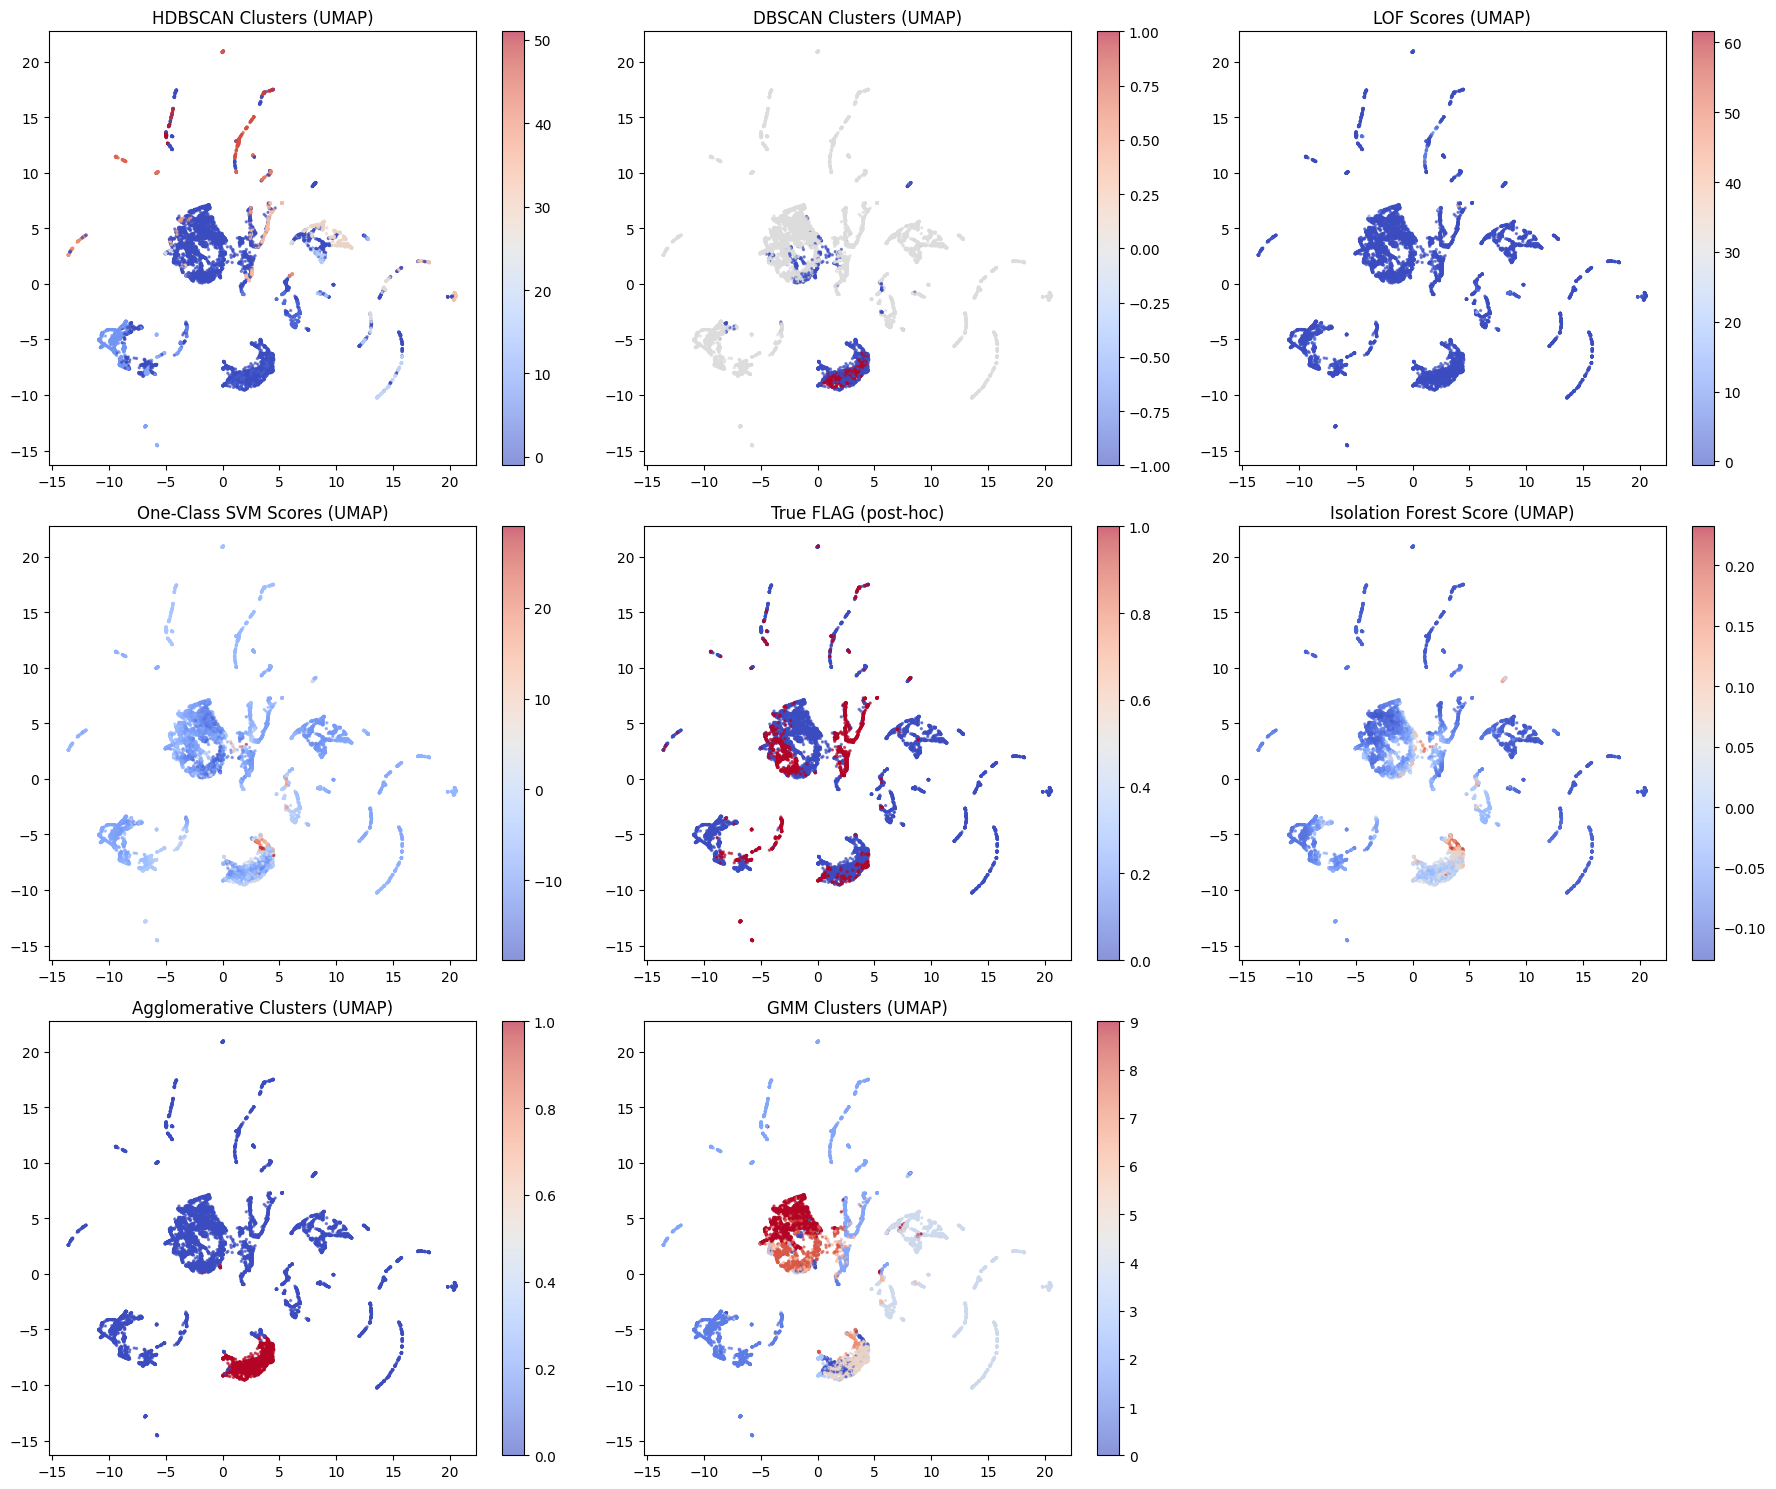

In [19]:
try:
    import umap.umap_ as umap

    # Fit UMAP on full dataset
    reducer = umap.UMAP(random_state=RANDOM_STATE, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_scaled)

    # Get scores for full dataset
    scores_if_full = -iso.decision_function(X_scaled)

    plt.figure(figsize=(18, 15)) # Increased figure size to accommodate 3 rows

    # Plot 1: HDBSCAN clusters
    plt.subplot(3, 3, 1) # Changed subplot indexing to 3 rows, 3 columns
    scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_hdbscan, cmap='coolwarm', s=2, alpha=0.6)
    plt.title("HDBSCAN Clusters (UMAP)")
    plt.colorbar(scatter)

    # Plot 2: DBSCAN clusters
    plt.subplot(3, 3, 2) # Changed subplot indexing
    scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_dbscan, cmap='coolwarm', s=2, alpha=0.6)
    plt.title("DBSCAN Clusters (UMAP)")
    plt.colorbar(scatter)

    # Plot 3: LOF scores
    plt.subplot(3, 3, 3) # Changed subplot indexing
    scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=scores_lof, cmap='coolwarm', s=2, alpha=0.6)
    plt.title("LOF Scores (UMAP)")
    plt.colorbar(scatter)

    # Plot 4: One-Class SVM scores
    plt.subplot(3, 3, 4) # Changed subplot indexing
    scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=scores_ocsvm, cmap='coolwarm', s=2, alpha=0.6)
    plt.title("One-Class SVM Scores (UMAP)")
    plt.colorbar(scatter)

    # Plot 5: True labels (post-hoc)
    plt.subplot(3, 3, 5) # Changed subplot indexing
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='coolwarm', s=2, alpha=0.6)
    plt.title("True FLAG (post‑hoc)")
    plt.colorbar()

    # Plot 6: Isolation Forest anomaly scores
    plt.subplot(3, 3, 6) # Changed subplot indexing
    scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=scores_if_full, cmap='coolwarm', s=2, alpha=0.6)
    plt.title("Isolation Forest Score (UMAP)")
    plt.colorbar()

    # Plot 7: Agglomerative Clustering labels
    plt.subplot(3, 3, 7) # New subplot
    scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_agg, cmap='coolwarm', s=2, alpha=0.6)
    plt.title("Agglomerative Clusters (UMAP)")
    plt.colorbar(scatter)

    # Plot 8: GMM labels
    plt.subplot(3, 3, 8) # New subplot
    scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_gmm, cmap='coolwarm', s=2, alpha=0.6)
    plt.title("GMM Clusters (UMAP)")
    plt.colorbar(scatter)

    plt.tight_layout()
    plt.show()

except ImportError:
    print("UMAP not installed. Skipping UMAP visualization.")
    print("To install: pip install umap-learn")

### PACMAP VISAULIZATION

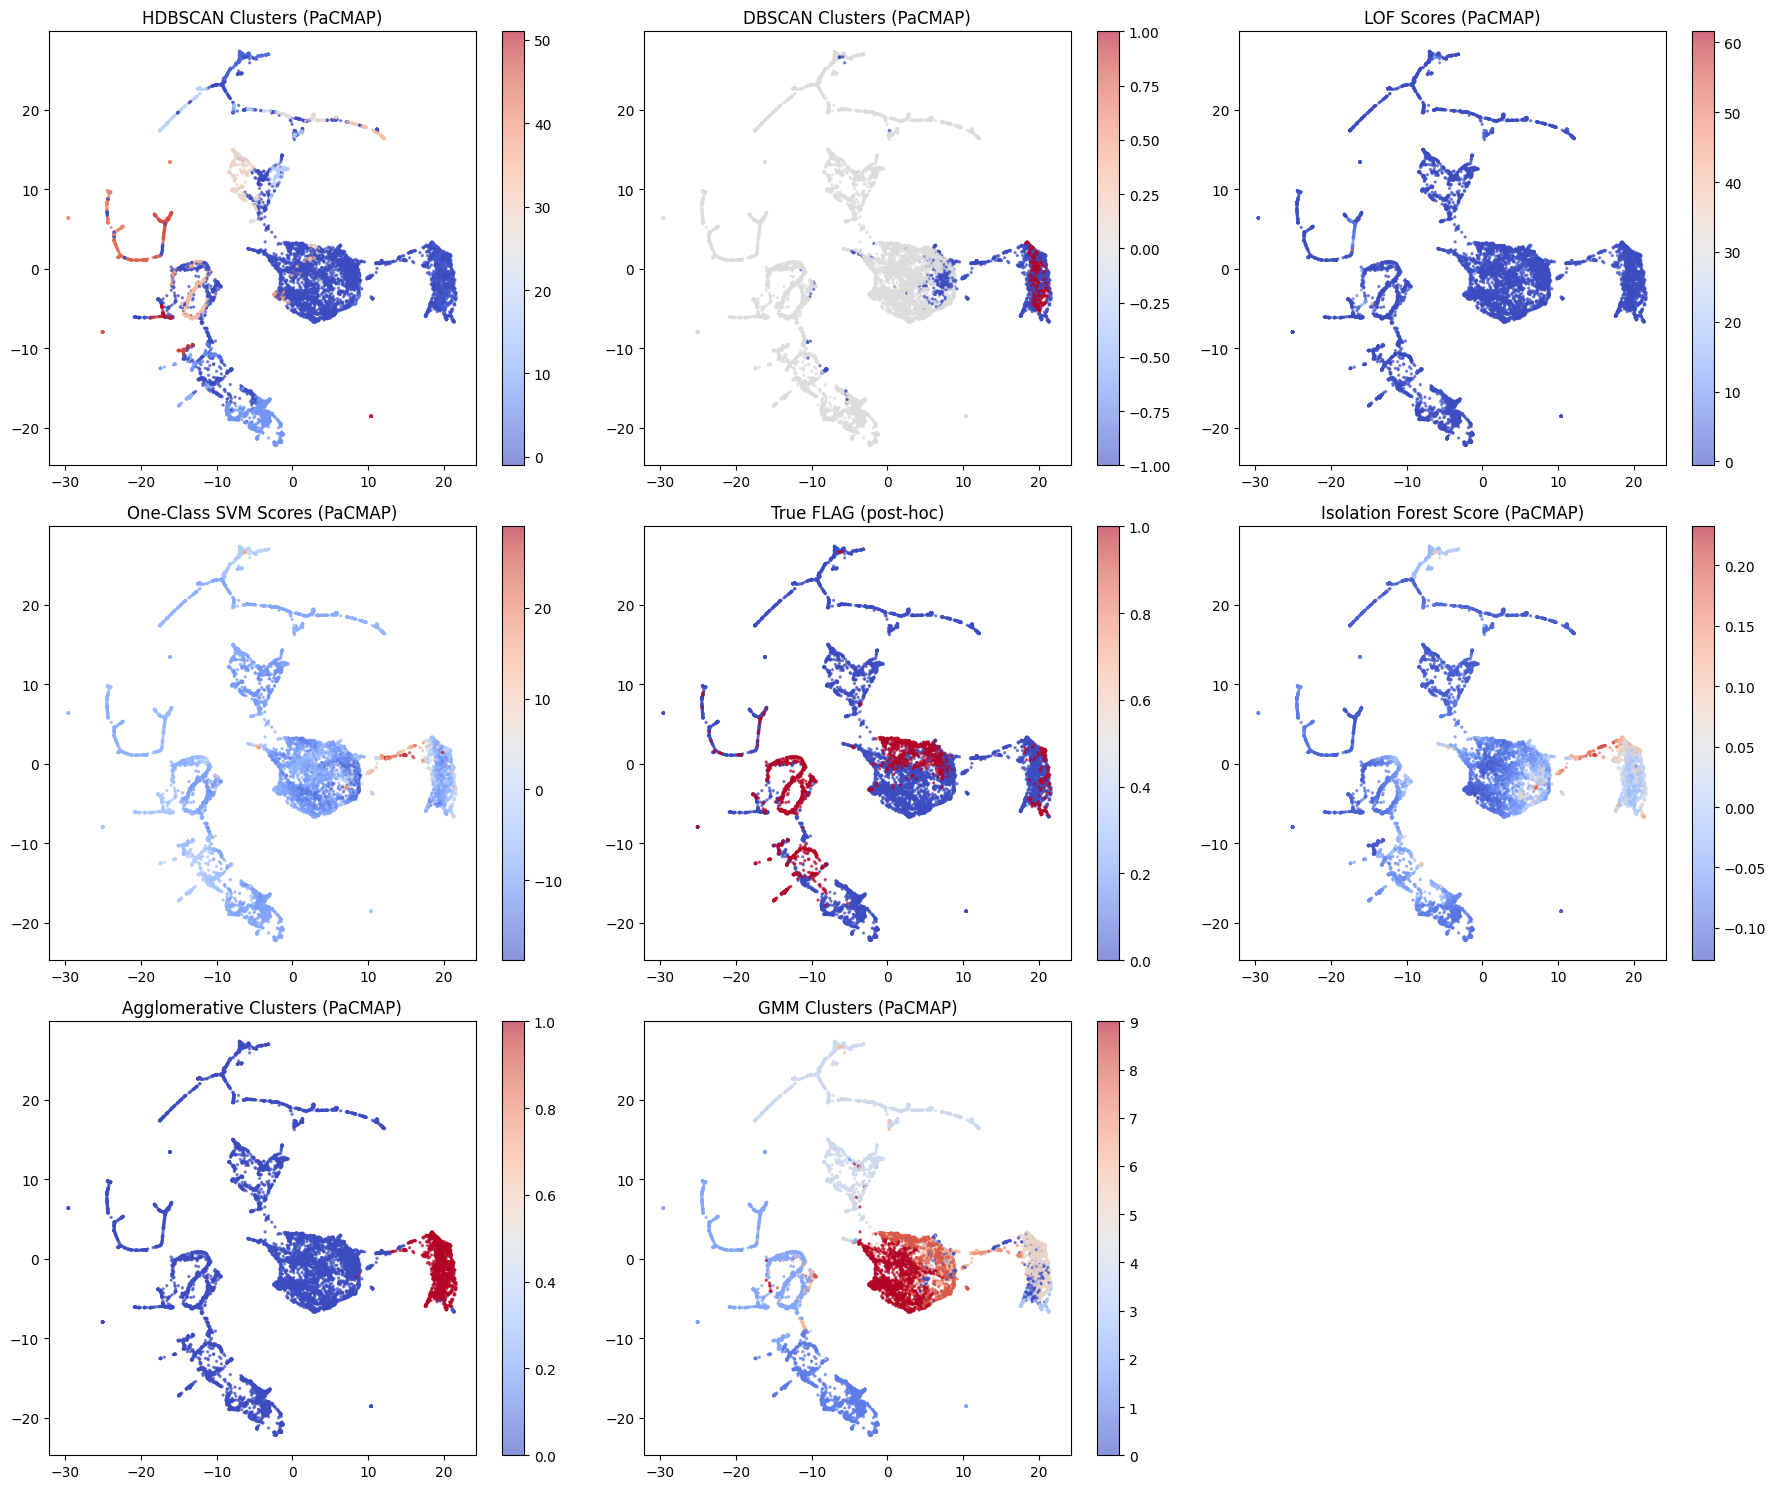

In [28]:
# ============================================================
# PaCMAP Visualization
# ============================================================

try:
    import pacmap

    # --------------------------------------------------------
    # Fit PaCMAP on the full dataset
    # --------------------------------------------------------
    reducer = pacmap.PaCMAP(
        n_components=2,
        n_neighbors=None,
        MN_ratio=0.5,
        FP_ratio=2.0,
        random_state=RANDOM_STATE
    )

    X_pacmap = reducer.fit_transform(X_scaled)

    # --------------------------------------------------------
    # Get Isolation Forest scores for full dataset
    # --------------------------------------------------------
    scores_if_full = -iso.decision_function(X_scaled)

    # --------------------------------------------------------
    # Create visualization
    # --------------------------------------------------------
    plt.figure(figsize=(18, 15))

    # --------------------------------------------------------
    # Plot 1: HDBSCAN clusters
    # --------------------------------------------------------
    plt.subplot(3, 3, 1)

    scatter = plt.scatter(
        X_pacmap[:, 0],
        X_pacmap[:, 1],
        c=labels_hdbscan,
        cmap="coolwarm",
        s=2,
        alpha=0.6
    )

    plt.title("HDBSCAN Clusters (PaCMAP)")
    plt.colorbar(scatter)

    # --------------------------------------------------------
    # Plot 2: DBSCAN clusters
    # --------------------------------------------------------
    plt.subplot(3, 3, 2)

    scatter = plt.scatter(
        X_pacmap[:, 0],
        X_pacmap[:, 1],
        c=labels_dbscan,
        cmap="coolwarm",
        s=2,
        alpha=0.6
    )

    plt.title("DBSCAN Clusters (PaCMAP)")
    plt.colorbar(scatter)

    # --------------------------------------------------------
    # Plot 3: LOF scores
    # --------------------------------------------------------
    plt.subplot(3, 3, 3)

    scatter = plt.scatter(
        X_pacmap[:, 0],
        X_pacmap[:, 1],
        c=scores_lof,
        cmap="coolwarm",
        s=2,
        alpha=0.6
    )

    plt.title("LOF Scores (PaCMAP)")
    plt.colorbar(scatter)

    # --------------------------------------------------------
    # Plot 4: One-Class SVM scores
    # --------------------------------------------------------
    plt.subplot(3, 3, 4)

    scatter = plt.scatter(
        X_pacmap[:, 0],
        X_pacmap[:, 1],
        c=scores_ocsvm,
        cmap="coolwarm",
        s=2,
        alpha=0.6
    )

    plt.title("One-Class SVM Scores (PaCMAP)")
    plt.colorbar(scatter)

    # --------------------------------------------------------
    # Plot 5: True labels (post-hoc)
    # --------------------------------------------------------
    plt.subplot(3, 3, 5)

    scatter = plt.scatter(
        X_pacmap[:, 0],
        X_pacmap[:, 1],
        c=y,
        cmap="coolwarm",
        s=2,
        alpha=0.6
    )

    plt.title("True FLAG (post-hoc)")
    plt.colorbar(scatter)

    # --------------------------------------------------------
    # Plot 6: Isolation Forest anomaly scores
    # --------------------------------------------------------
    plt.subplot(3, 3, 6)

    scatter = plt.scatter(
        X_pacmap[:, 0],
        X_pacmap[:, 1],
        c=scores_if_full,
        cmap="coolwarm",
        s=2,
        alpha=0.6
    )

    plt.title("Isolation Forest Score (PaCMAP)")
    plt.colorbar(scatter)

    # --------------------------------------------------------
    # Plot 7: Agglomerative Clustering labels
    # --------------------------------------------------------
    plt.subplot(3, 3, 7)

    scatter = plt.scatter(
        X_pacmap[:, 0],
        X_pacmap[:, 1],
        c=labels_agg,
        cmap="coolwarm",
        s=2,
        alpha=0.6
    )

    plt.title("Agglomerative Clusters (PaCMAP)")
    plt.colorbar(scatter)

    # --------------------------------------------------------
    # Plot 8: GMM labels
    # --------------------------------------------------------
    plt.subplot(3, 3, 8)

    scatter = plt.scatter(
        X_pacmap[:, 0],
        X_pacmap[:, 1],
        c=labels_gmm,
        cmap="coolwarm",
        s=2,
        alpha=0.6
    )

    plt.title("GMM Clusters (PaCMAP)")
    plt.colorbar(scatter)

    # --------------------------------------------------------
    # Final layout
    # --------------------------------------------------------
    plt.tight_layout()
    plt.show()


except ImportError:

    print("PaCMAP not installed. Skipping PaCMAP visualization.")
    print("To install: pip install pacmap")



## PART D — MODEL COMPARISON
#### We create comparison tables for clustering and anomaly detection.

---
### 8.1 Clustering Comparison Table

In [20]:
# Compute internal metrics
metrics_gmm = cluster_metrics(X_scaled, labels_gmm)
metrics_hdbscan = cluster_metrics(X_scaled, labels_hdbscan)
metrics_dbscan = cluster_metrics(X_scaled, labels_dbscan)
metrics_agg = cluster_metrics(X_scaled, labels_agg)

# Compute external metrics (post-hoc)
external_gmm = external_cluster_metrics(labels_gmm, y)
external_hdbscan = external_cluster_metrics(labels_hdbscan, y)
external_dbscan = external_cluster_metrics(labels_dbscan, y)
external_agg = external_cluster_metrics(labels_agg, y)

# Compute fraud purity
purity_gmm = fraud_purity(labels_gmm, y)
purity_hdbscan = fraud_purity(labels_hdbscan, y)
purity_dbscan = fraud_purity(labels_dbscan, y)
purity_agg = fraud_purity(labels_agg, y)

In [21]:
clustering_compare = pd.DataFrame({
    "Model": ["GMM", "HDBSCAN", "DBSCAN", "Agglomerative"],

    "Clusters": [
        best_n,
        n_clusters_hdb,
        n_clusters_db,
        best_agg_n
    ],

    "Noise %": [
        0,
        noise_hdb / len(labels_hdbscan) * 100,
        noise_db / len(labels_dbscan) * 100,
        0
    ],

    # ---------------------------
    # INTERNAL METRICS
    # ---------------------------
    "Silhouette": [
        metrics_gmm["silhouette"],
        metrics_hdbscan["silhouette"],
        metrics_dbscan["silhouette"],
        metrics_agg["silhouette"]
    ],

    "Davies-Bouldin": [
        metrics_gmm["db"],
        metrics_hdbscan["db"],
        metrics_dbscan["db"],
        metrics_agg["db"]
    ],

    "Calinski-Harabasz": [
        metrics_gmm["ch"],
        metrics_hdbscan["ch"],
        metrics_dbscan["ch"],
        metrics_agg["ch"]
    ],

    "DBCV": [
        metrics_gmm["dbcv"],
        metrics_hdbscan["dbcv"],
        metrics_dbscan["dbcv"],
        metrics_agg["dbcv"]
    ],

    # ---------------------------
    # EXTERNAL METRICS (post-hoc)
    # ---------------------------
    "ARI": [
        external_gmm["ARI"],
        external_hdbscan["ARI"],
        external_dbscan["ARI"],
        external_agg["ARI"]
    ],

    "NMI": [
        external_gmm["NMI"],
        external_hdbscan["NMI"],
        external_dbscan["NMI"],
        external_agg["NMI"]
    ],

    "Homogeneity": [
        external_gmm["Homogeneity"],
        external_hdbscan["Homogeneity"],
        external_dbscan["Homogeneity"],
        external_agg["Homogeneity"]
    ],

    "Completeness": [
        external_gmm["Completeness"],
        external_hdbscan["Completeness"],
        external_dbscan["Completeness"],
        external_agg["Completeness"]
    ],

    "V-measure": [
        external_gmm["V-measure"],
        external_hdbscan["V-measure"],
        external_dbscan["V-measure"],
        external_agg["V-measure"]
    ],

    # ---------------------------
    # FRAUD-SPECIFIC POST-HOC
    # ---------------------------
    "Fraud Purity": [
        purity_gmm,
        purity_hdbscan,
        purity_dbscan,
        purity_agg
    ],

    "Best Fraud Rate": [
        stats_gmm["fraud_rate"].max(),
        stats_hdb["fraud_rate"].max() if not stats_hdb.empty else np.nan,
        stats_db["fraud_rate"].max() if not stats_db.empty else np.nan,
        stats_agg["fraud_rate"].max()
    ],

    "Best Enrichment": [
        stats_gmm["enrichment"].max(),
        stats_hdb["enrichment"].max() if not stats_hdb.empty else np.nan,
        stats_db["enrichment"].max() if not stats_db.empty else np.nan,
        stats_agg["enrichment"].max()
    ],

    "Best Fraud Coverage": [
        stats_gmm["fraud_coverage"].max(),
        stats_hdb["fraud_coverage"].max() if not stats_hdb.empty else np.nan,
        stats_db["fraud_coverage"].max() if not stats_db.empty else np.nan,
        stats_agg["fraud_coverage"].max()
    ]
})

print("\nClustering Comparison:")
print(clustering_compare.round(3).to_string(index=False))


Clustering Comparison:
        Model  Clusters  Noise %  Silhouette  Davies-Bouldin  Calinski-Harabasz   DBCV    ARI   NMI  Homogeneity  Completeness  V-measure  Fraud Purity  Best Fraud Rate  Best Enrichment  Best Fraud Coverage
          GMM        10    0.000       0.203           2.748           1925.238 -0.783  0.028 0.066        0.178         0.040      0.066         0.411            0.411            2.308                0.340
      HDBSCAN        52   57.031       0.386           0.892            584.343  0.177  0.044 0.177        0.772         0.100      0.177         1.000            1.000            5.613                0.159
       DBSCAN         2   13.846       0.639           0.617           6893.883  0.128 -0.066 0.023        0.018         0.031      0.023         0.196            0.196            1.102                0.875
Agglomerative         2    0.000       0.578           0.774           8065.139 -0.795 -0.047 0.008        0.007         0.008      0.008         0.

### 8.2 Anomaly Detection Comparison Table

In [22]:
# Combine results
anomaly_results = [if_results, lof_results, oc_results]
anomaly_compare = pd.DataFrame({
    "Model": [r["model"] for r in anomaly_results],
    "PR-AUC": [r["pr_auc"] for r in anomaly_results],
    "ROC-AUC": [r["roc_auc"] for r in anomaly_results],  # diagnostic
})

# Add top‑k metrics for each model (at 1%, 5%, 10%)
for k_frac in [0.01, 0.05, 0.10]:
    for metric in ["Precision", "Fraud_Capture", "Lift"]:
        col = f"{metric}@{int(k_frac*100)}%"
        anomaly_compare[col] = [
            r["top_metrics"][r["top_metrics"]["Top_K"]==f"{int(k_frac*100)}%"][metric].values[0]
            for r in anomaly_results
        ]

# Add random baseline
random_baseline = {
    "Model": "Random Ranking Baseline",
    "PR-AUC": overall_fraud_rate,
    "ROC-AUC": 0.5,
}
for k_frac in [0.01, 0.05, 0.10]:
    random_baseline[f"Precision@{int(k_frac*100)}%"] = overall_fraud_rate
    random_baseline[f"Fraud_Capture@{int(k_frac*100)}%"] = k_frac
    random_baseline[f"Lift@{int(k_frac*100)}%"] = 1.0

anomaly_compare = pd.concat([anomaly_compare, pd.DataFrame([random_baseline])], ignore_index=True)

print("Anomaly Detection Comparison:\n", anomaly_compare.round(3))

Anomaly Detection Comparison:
                      Model  PR-AUC  ROC-AUC  Precision@1%  Fraud_Capture@1%  \
0         Isolation Forest   0.171    0.531         0.011             0.001   
1               LOF (n=50)   0.176    0.481         0.204             0.011   
2            One‑Class SVM   0.190    0.534         0.097             0.005   
3  Random Ranking Baseline   0.178    0.500         0.178             0.010   

   Lift@1%  Precision@5%  Fraud_Capture@5%  Lift@5%  Precision@10%  \
0    0.060         0.103             0.029    0.579          0.108   
1    1.147         0.181             0.051    1.014          0.189   
2    0.543         0.116             0.033    0.652          0.175   
3    1.000         0.178             0.050    1.000          0.178   

   Fraud_Capture@10%  Lift@10%  
0              0.060     0.604  
1              0.106     1.062  
2              0.098     0.984  
3              0.100     1.000  


### 9. Final Interpretation
We automatically generate a concise summary based on the actual results.

**Note:** All clustering models were selected using internal unsupervised metrics; fraud labels were used only for post-hoc evaluation. Anomaly detection models were trained without fraud labels; scores were evaluated post-hoc.

In [23]:
print("\n" + "="*80)
print("FINAL INTERPRETATION")
print("="*80)

# Determine best models across internal metrics
best_sil_model = clustering_compare.loc[clustering_compare["Silhouette"].idxmax(), "Model"]
best_sil_score = clustering_compare["Silhouette"].max()

best_db_model = clustering_compare.loc[clustering_compare["Davies-Bouldin"].idxmin(), "Model"]
best_db_score = clustering_compare["Davies-Bouldin"].min()

best_ch_model = clustering_compare.loc[clustering_compare["Calinski-Harabasz"].idxmax(), "Model"]
best_ch_score = clustering_compare["Calinski-Harabasz"].max()

# DBCV – only meaningful for models that have it (HDBSCAN, DBSCAN usually)
dbcv_subset = clustering_compare.dropna(subset=["DBCV"])
if not dbcv_subset.empty:
    best_dbcv_model = dbcv_subset.loc[dbcv_subset["DBCV"].idxmax(), "Model"]
    best_dbcv_score = dbcv_subset["DBCV"].max()
else:
    best_dbcv_model = "N/A (all NaN)"
    best_dbcv_score = np.nan

# Best external metrics (post-hoc, using FLAG)
best_ari_model = clustering_compare.loc[clustering_compare["ARI"].idxmax(), "Model"]
best_ari_score = clustering_compare["ARI"].max()

best_nmi_model = clustering_compare.loc[clustering_compare["NMI"].idxmax(), "Model"]
best_nmi_score = clustering_compare["NMI"].max()

best_v_model = clustering_compare.loc[clustering_compare["V-measure"].idxmax(), "Model"]
best_v_score = clustering_compare["V-measure"].max()

# Fraud-specific post-hoc
best_purity_model = clustering_compare.loc[clustering_compare["Fraud Purity"].idxmax(), "Model"]
best_purity_score = clustering_compare["Fraud Purity"].max()

best_enrich_model = clustering_compare.loc[clustering_compare["Best Enrichment"].idxmax(), "Model"]
best_enrich_score = clustering_compare["Best Enrichment"].max()

best_coverage_model = clustering_compare.loc[clustering_compare["Best Fraud Coverage"].idxmax(), "Model"]
best_coverage_score = clustering_compare["Best Fraud Coverage"].max()

# Overall fraud prevalence
overall_fraud_rate = y.mean()

print(f"1. Best clustering model by internal silhouette: {best_sil_model} (Silhouette = {best_sil_score:.3f}).")
print(f"2. Best by Davies-Bouldin (lower is better): {best_db_model} (DB = {best_db_score:.3f}).")
print(f"3. Best by Calinski-Harabasz: {best_ch_model} (CH = {best_ch_score:.1f}).")
if not np.isnan(best_dbcv_score):
    print(f"4. Best by DBCV (density-based, higher is better): {best_dbcv_model} (DBCV = {best_dbcv_score:.3f}).")
else:
    print("4. DBCV could not be computed for any model (clusters too small or other issues).")

print("\nPost-hoc evaluation using the known FLAG labels (not used for training):")
print(f"5. Best agreement with true fraud labels (ARI): {best_ari_model} (ARI = {best_ari_score:.3f}).")
print(f"6. Best mutual information with true fraud labels (NMI): {best_nmi_model} (NMI = {best_nmi_score:.3f}).")
print(f"7. Best balance of homogeneity & completeness (V-measure): {best_v_model} (V = {best_v_score:.3f}).")

print("\nFraud concentration / separation metrics (post-hoc):")
print(f"8. Highest fraud purity in a cluster: {best_purity_model} (purity = {best_purity_score:.2%}).")
print(f"9. Highest enrichment over baseline: {best_enrich_model} ({best_enrich_score:.2f}x baseline).")
print(f"10. Best coverage of all fraud cases in a single cluster: {best_coverage_model} (covers {best_coverage_score:.1%} of all fraud).")

print(f"\nOverall fraud prevalence: {overall_fraud_rate:.2%}.")

print("\nKey insights:")
print("- Clustering internal metrics (Silhouette, DBCV, etc.) indicate that DBSCAN and HDBSCAN find geometrically separated groups, but they produce many noise points.")
print("- External metrics (ARI, NMI) show that clusters do not perfectly match the fraud labels; fraud is not fully separable into one cluster.")
print("- Some clusters have high fraud purity (>40% for GMM, >90% for HDBSCAN small clusters), meaning unsupervised structure captures extreme fraud behavior.")
print("- However, coverage is low for those pure clusters – they are very small, so they miss most fraud cases.")
print("- This suggests that fraud manifests in different behavioral patterns, not a single uniform group.")
print("- UMAP visualizations support this: fraud points are scattered, not forming a single dense region.")
print("\nLimitations:")
print("- Results are dataset‑specific; they may not generalize to other Ethereum transaction data.")
print("- Unsupervised model selection used only internal metrics (no FLAG).")
print("- DBCV is sensitive to cluster size; it may fail for very small clusters.")


FINAL INTERPRETATION
1. Best clustering model by internal silhouette: DBSCAN (Silhouette = 0.639).
2. Best by Davies-Bouldin (lower is better): DBSCAN (DB = 0.617).
3. Best by Calinski-Harabasz: Agglomerative (CH = 8065.1).
4. Best by DBCV (density-based, higher is better): HDBSCAN (DBCV = 0.177).

Post-hoc evaluation using the known FLAG labels (not used for training):
5. Best agreement with true fraud labels (ARI): HDBSCAN (ARI = 0.044).
6. Best mutual information with true fraud labels (NMI): HDBSCAN (NMI = 0.177).
7. Best balance of homogeneity & completeness (V-measure): HDBSCAN (V = 0.177).

Fraud concentration / separation metrics (post-hoc):
8. Highest fraud purity in a cluster: HDBSCAN (purity = 100.00%).
9. Highest enrichment over baseline: HDBSCAN (5.61x baseline).
10. Best coverage of all fraud cases in a single cluster: Agglomerative (covers 91.9% of all fraud).

Overall fraud prevalence: 17.82%.

Key insights:
- Clustering internal metrics (Silhouette, DBCV, etc.) indica